**WINE DATASET WITH CHEMICAL PROPERTIES AND QUALITY RATINGS**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('wine_dataset_raw_600_rows.csv')
df.head()

Saving wine_dataset_raw_600_rows.csv to wine_dataset_raw_600_rows.csv


,fixed acidity,volatile acidity,citric acid,RESIDUAL SUGAR,chlorides,FREE SULFUR DIOXIDE,TOTAL SULFUR DIOXIDE,DENSITY,quality
0,8.11994,0.336509,NaN,14.36927,0.074715,47.4165,47.5197,1.0027494,5.0
1,14.45786,0.490026,NaN,11.19387,0.023625,55.971,173.838,0.9929437,3.0
2,12.05193,0.347815,0.0221236,5.62215,0.087829,18.2823,60.4695,0.9918832,6.0
3,10.58524,NaN,NaN,4.79977,0.069131,44.1163,87.9211,1.0044522,NaN
4,5.71621,0.26889,0.4886432,NaN,0.138653,40.4505A,70.3007,0.9916207,5.0


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   fixed acidity         571 non-null    object
 1   volatile acidity      571 non-null    object
 2   citric acid           571 non-null    object
 3   RESIDUAL SUGAR        573 non-null    object
 4   chlorides             570 non-null    object
 5   FREE SULFUR DIOXIDE   570 non-null    object
 6   TOTAL SULFUR DIOXIDE  571 non-null    object
 7   DENSITY               572 non-null    object
 8   quality               571 non-null    object
dtypes: object(9)
memory usage: 42.3+ KB


,fixed acidity,volatile acidity,citric acid,RESIDUAL SUGAR,chlorides,FREE SULFUR DIOXIDE,TOTAL SULFUR DIOXIDE,DENSITY,quality
count,571,571,571,573,570,570,571,572,571
unique,571,571,571,571,570,570,571,570,12
top,4.44955,0.282121,0.0121085,nanb,0.175569,46.655,187.4291,0.9909306,4.0
freq,1,1,1,3,1,1,1,2,119


**PHASE_02**

Clean Column Names

In [5]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

Remove Alpha + Convert Text to Numeric

In [6]:
for col in df.columns:
    df[col] = df[col].astype(str).str.replace(r'[^0-9.]', '', regex=True)

df = df.apply(pd.to_numeric, errors='coerce')

Handle Missing Values

In [7]:
df.isnull().sum()
df = df.fillna(df.median())

Remove Duplicates

In [8]:
df = df.drop_duplicates()

Handle Outliers

In [9]:
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

Final Check

In [10]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         600 non-null    float64
 1   volatile_acidity      600 non-null    float64
 2   citric_acid           600 non-null    float64
 3   residual_sugar        600 non-null    float64
 4   chlorides             600 non-null    float64
 5   free_sulfur_dioxide   600 non-null    float64
 6   total_sulfur_dioxide  600 non-null    float64
 7   density               600 non-null    float64
 8   quality               600 non-null    float64
dtypes: float64(9)
memory usage: 42.3 KB


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,quality
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,9.581600,0.785670,0.499490,7.768309,0.106215,35.179912,148.484326,0.997423,5.431667
std,3.193275,0.396758,0.283062,4.048212,0.054239,19.171715,82.325117,0.004169,1.661304
min,4.055680,0.106485,0.004940,0.522690,0.010002,1.137500,6.009000,0.990003,3.000000
25%,6.899567,0.433121,0.248343,4.435553,0.063600,18.857100,80.710550,0.993848,4.000000
50%,9.747370,0.793957,0.500727,7.932390,0.105096,35.603200,144.037300,0.997394,5.000000
75%,12.290363,1.123689,0.720486,11.111430,0.153958,50.471800,215.558050,1.000865,7.000000
max,14.996890,1.497108,0.999414,14.976040,0.199586,69.923600,299.870000,1.004966,8.000000


Save Clean Dataset

In [11]:
df.to_csv('wine_cleaned.csv', index=False)

files.download('wine_cleaned.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

VISUALIZATION SECTION

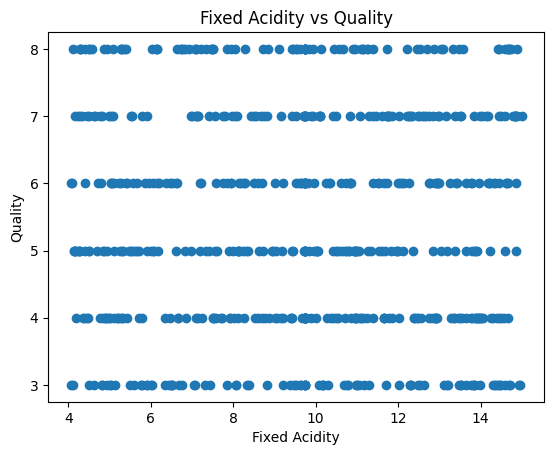

In [12]:
plt.scatter(df['fixed_acidity'], df['quality'])
plt.xlabel('Fixed Acidity')
plt.ylabel('Quality')
plt.title('Fixed Acidity vs Quality')
plt.show()

Histogram

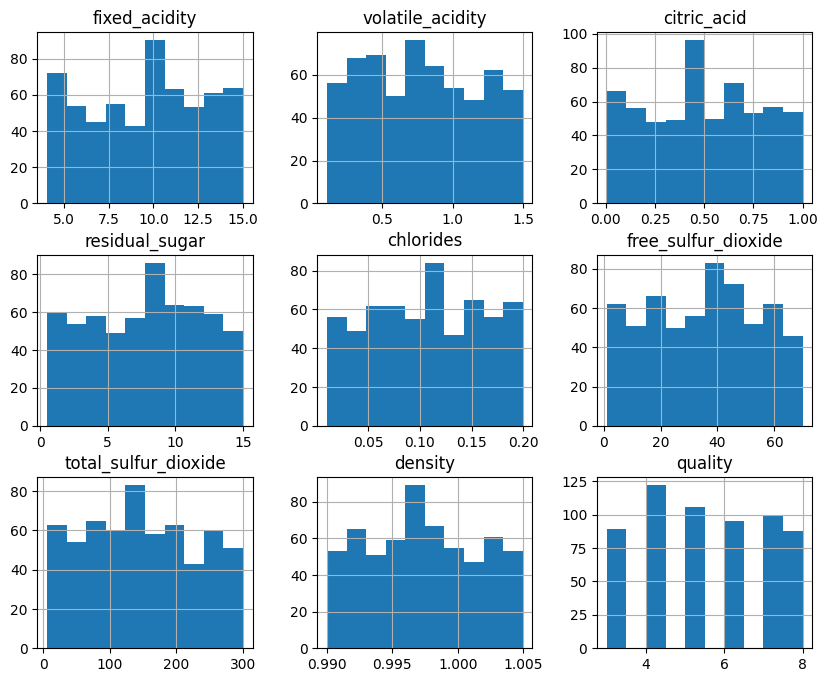

In [13]:
df.hist(figsize=(10,8))
plt.show()

Feature Correlation

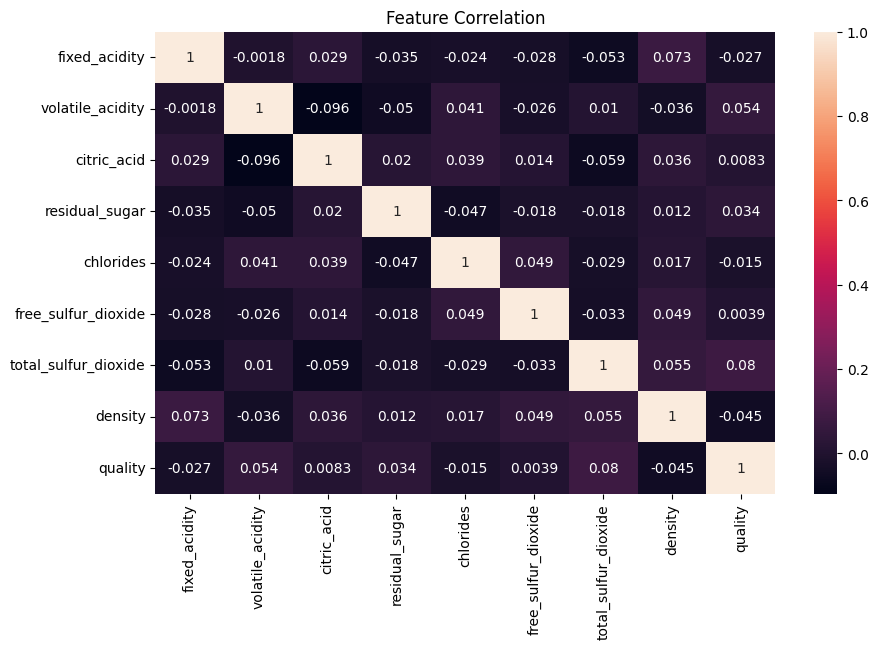

In [14]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

Regression Line

In [35]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [37]:

y_pred = model.predict(X)

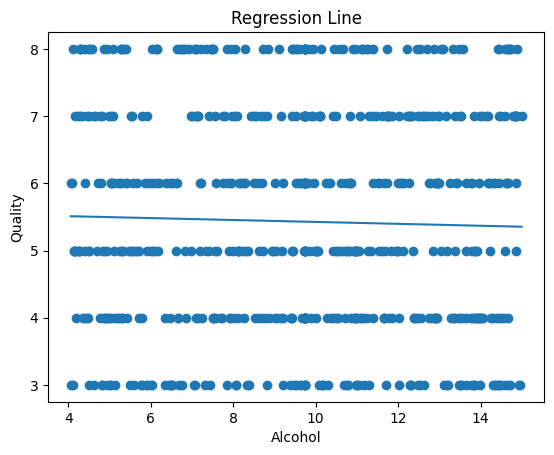

In [39]:

import numpy as np

X_values = X.values.flatten()
sorted_index = np.argsort(X_values)

plt.scatter(X, y)
plt.plot(X_values[sorted_index], y_pred[sorted_index])

plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.title("Regression Line")

plt.show()

Actual vs Predicted

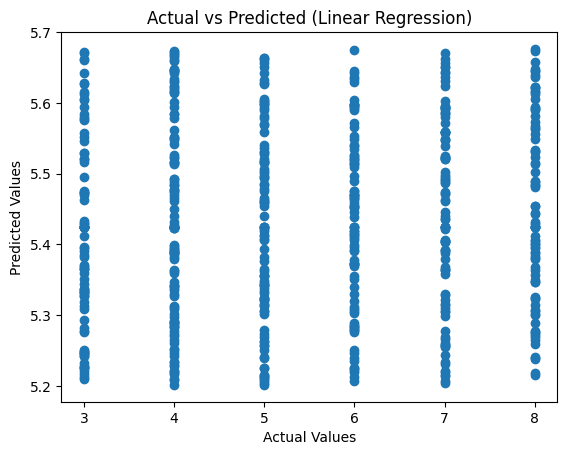

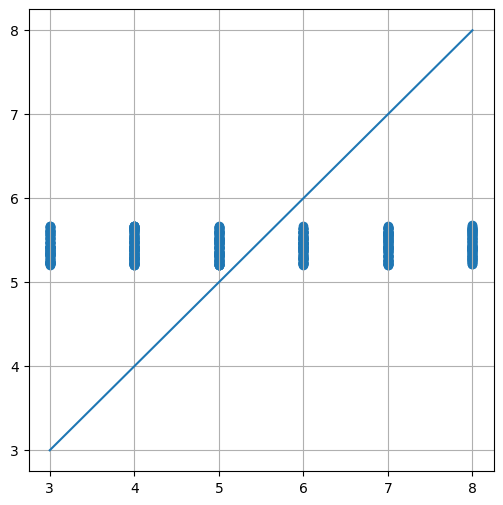

In [45]:
X = df[['total_sulfur_dioxide']]
y = df['quality']
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)
import matplotlib.pyplot as plt

plt.scatter(y, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted (Linear Regression)")
plt.figure(figsize=(6,6))
plt.scatter(y, y_pred)

line = np.linspace(min(y), max(y), 100)
plt.plot(line, line)

plt.grid()
plt.show()


Gradient Decent

Epoch 0, Loss: 32.25833333333333
Epoch 20, Loss: 15.903684524069195
Epoch 40, Loss: 8.614410943304232
Epoch 60, Loss: 5.365578763848291
Epoch 80, Loss: 3.9175729490959292
Epoch 100, Loss: 3.2721961725374777
Epoch 120, Loss: 2.984551482524812
Epoch 140, Loss: 2.85634812799182
Epoch 160, Loss: 2.7992078410885983
Epoch 180, Loss: 2.77374039213396


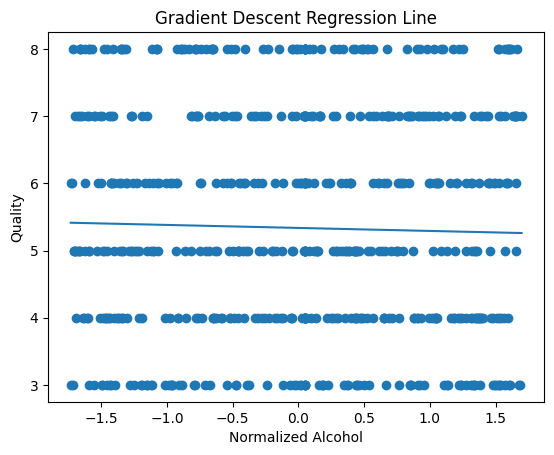

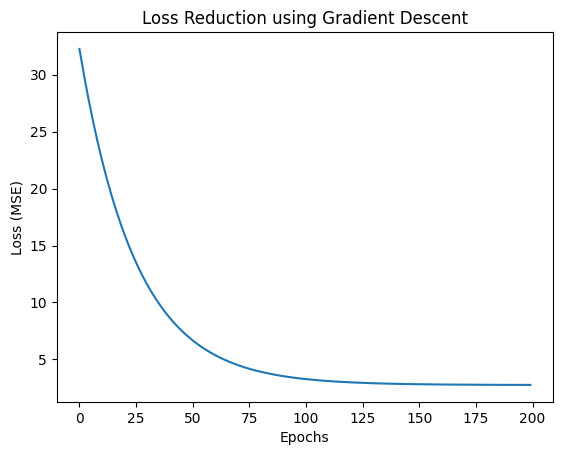

In [49]:
x = df['fixed_acidity'].values
y = df['quality'].values
import numpy as np

x = (x - x.mean()) / x.std()
m = 0.0   # slope
b = 0.0   # intercept

learning_rate = 0.01
epochs = 200

n = len(x)
loss_history = []

for i in range(epochs):
    y_pred = m * x + b

    # gradients
    dm = (-2/n) * np.sum(x * (y - y_pred))
    db = (-2/n) * np.sum(y - y_pred)

    # update
    m = m - learning_rate * dm
    b = b - learning_rate * db

    # loss (MSE)
    loss = np.mean((y - y_pred)**2)
    loss_history.append(loss)

    if i % 20 == 0:
        print(f"Epoch {i}, Loss: {loss}")
        import matplotlib.pyplot as plt


sorted_idx = np.argsort(x)

plt.scatter(x, y)
plt.plot(x[sorted_idx], (m * x + b)[sorted_idx])

plt.xlabel("Normalized Alcohol")
plt.ylabel("Quality")
plt.title("Gradient Descent Regression Line")

plt.show()
plt.plot(loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Loss Reduction using Gradient Descent")
plt.show()

Confusion Matrix

[[48 15]
 [44 13]]


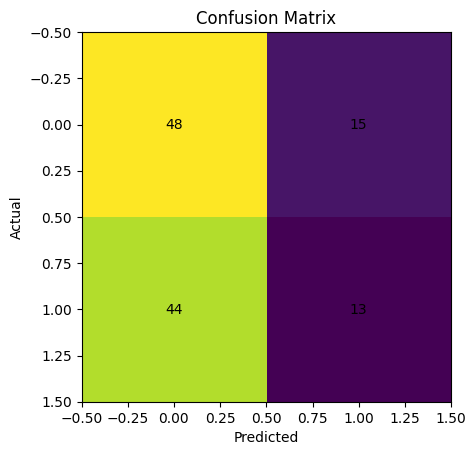

In [50]:
y_class = (df['quality'] >= 6).astype(int)

X = df.drop('quality', axis=1)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_class, test_size=0.2, random_state=42
)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)
import matplotlib.pyplot as plt

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j], ha='center', va='center')

plt.show()

KNN Confusion Matrix

In [51]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

[[32 31]
 [31 26]]


**PHASE 3**

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

Define X and y

In [16]:
X = df.drop('quality', axis=1)
y = df['quality']

Feature Scaling

In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

LINEAR REGRESSION

Select Important Features

In [52]:
corr = df.corr()['quality'].abs().sort_values(ascending=False)
print(corr)

# take top 3–5 best features
top_features = corr.index[1:5]

X = df[top_features]
y = df['quality']

quality                 1.000000
total_sulfur_dioxide    0.080100
volatile_acidity        0.054453
density                 0.045257
residual_sugar          0.034325
fixed_acidity           0.027396
chlorides               0.014757
citric_acid             0.008293
free_sulfur_dioxide     0.003902
Name: quality, dtype: float64


Remove Outliers

In [53]:
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

mask = ~((X < (Q1 - 1.5 * IQR)) | (X > (Q3 + 1.5 * IQR))).any(axis=1)

X = X[mask]
y = y[mask]

Feature Scaling

In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train-Test Split

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

Train Linear Regression

In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Calculate Metrics

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

n = len(y_test)
p = X.shape[1]

adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("🔹 Linear Regression Results")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 :", r2)
print("Adjusted R2:", adj_r2)

🔹 Linear Regression Results
MAE : 1.430383459434864
MSE : 2.658355148602413
RMSE: 1.630446303501717
R2 : 0.021439348146047865
Adjusted R2: -0.012597544092350477


LOGISTIC REGRESSION

In [58]:
# STEP 1: Prepare classification target
y_class = (df['quality'] >= 6).astype(int)

X = df.drop('quality', axis=1)

# STEP 2: Scale data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# STEP 3: Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_class, test_size=0.2, random_state=42
)

# STEP 4: Train model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# STEP 5: Predictions
y_pred = model.predict(X_test)

# STEP 6: Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.5083333333333333
Precision: 0.4642857142857143
Recall: 0.22807017543859648
Confusion Matrix:
 [[48 15]
 [44 13]]


KNN CLASSIFIER

In [59]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("\nKNN Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:\n", cm_knn)


KNN Results:
Accuracy: 0.48333333333333334
Precision: 0.45614035087719296
Recall: 0.45614035087719296
F1 Score: 0.45614035087719296
Confusion Matrix:
 [[32 31]
 [31 26]]


K-MEANS (UNSUPERVISED)

Elbow Method

In [28]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)

print("WCSS (Inertia):", kmeans.inertia_)

WCSS (Inertia): 4040.6191682629906


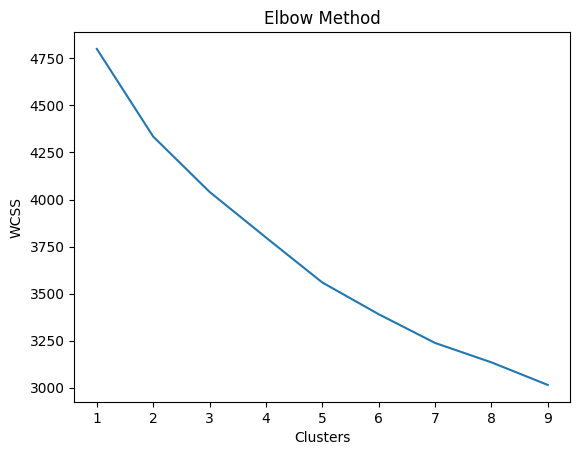

In [60]:
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.plot(range(1, 10), wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

Apply K-Means

In [61]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

In [62]:
mae_km = mean_absolute_error(y, clusters)
mse_km = mean_squared_error(y, clusters)
r2_km = r2_score(y, clusters)

n = len(y)
p = X.shape[1]

adj_r2_km = 1 - (1 - r2_km) * (n - 1) / (n - p - 1)

print("\nK-Means Results:")
print("MAE:", mae_km)
print("MSE:", mse_km)



K-Means Results:
MAE: 4.468333333333334
MSE: 23.215
